# Phase 4 — Model Evaluation

---
## Step 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, balanced_accuracy_score
)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':130,'axes.titlesize':12,'axes.labelsize':10,'legend.fontsize':9})
COLORS = {'lr':'#3498db','rf':'#2ecc71','xgb':'#e74c3c'}
print('Libraries loaded!')

Libraries loaded!


---
## Step 2 — Data Preparation & Model Training

In [2]:
df = pd.read_csv('creditcard.csv')
X  = df.drop('Class', axis=1).copy()
y  = df['Class'].copy()

scaler = StandardScaler()
X[['Amount','Time']] = scaler.fit_transform(X[['Amount','Time']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_tr, y_tr = SMOTE(random_state=42, k_neighbors=5).fit_resample(X_train, y_train)

print(f'Train (SMOTE): {X_tr.shape[0]:,} | Test (raw): {X_test.shape[0]:,}')
print(f'Test fraud cases: {(y_test==1).sum()} out of {len(y_test):,}')

Train (SMOTE): 454,902 | Test (raw): 56,962
Test fraud cases: 98 out of 56,962


In [3]:
model_defs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=0.01),
    'Random Forest':       RandomForestClassifier(n_estimators=20, max_depth=8, min_samples_leaf=10, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss', n_jobs=-1, verbosity=0)
}

results = {}
for name, model in model_defs.items():
    print(f'Training {name}...', end=' ')
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    tn,fp,fn,tp = confusion_matrix(y_test, y_pred).ravel()
    results[name] = {
        'model':model,'y_pred':y_pred,'y_prob':y_prob,
        'auc':roc_auc_score(y_test,y_prob),
        'ap':average_precision_score(y_test,y_prob),
        'prec':precision_score(y_test,y_pred),
        'rec':recall_score(y_test,y_pred),
        'f1':f1_score(y_test,y_pred),
        'mcc':matthews_corrcoef(y_test,y_pred),
        'bal_acc':balanced_accuracy_score(y_test,y_pred),
        'cm':confusion_matrix(y_test,y_pred),'time':elapsed
    }
    print(f'Done ({elapsed:.1f}s) | AUC={results[name]["auc"]:.4f} | Recall={results[name]["rec"]:.4f} | FN={fn}')
print('All models trained!')

Training Logistic Regression... Done (1.4s) | AUC=0.9700 | Recall=0.9184 | FN=8
Training Random Forest... Done (9.2s) | AUC=0.9788 | Recall=0.8776 | FN=12
Training XGBoost... Done (3.3s) | AUC=0.9769 | Recall=0.8878 | FN=11
All models trained!


---
## Step 3 — Confusion Matrices (Annotated)

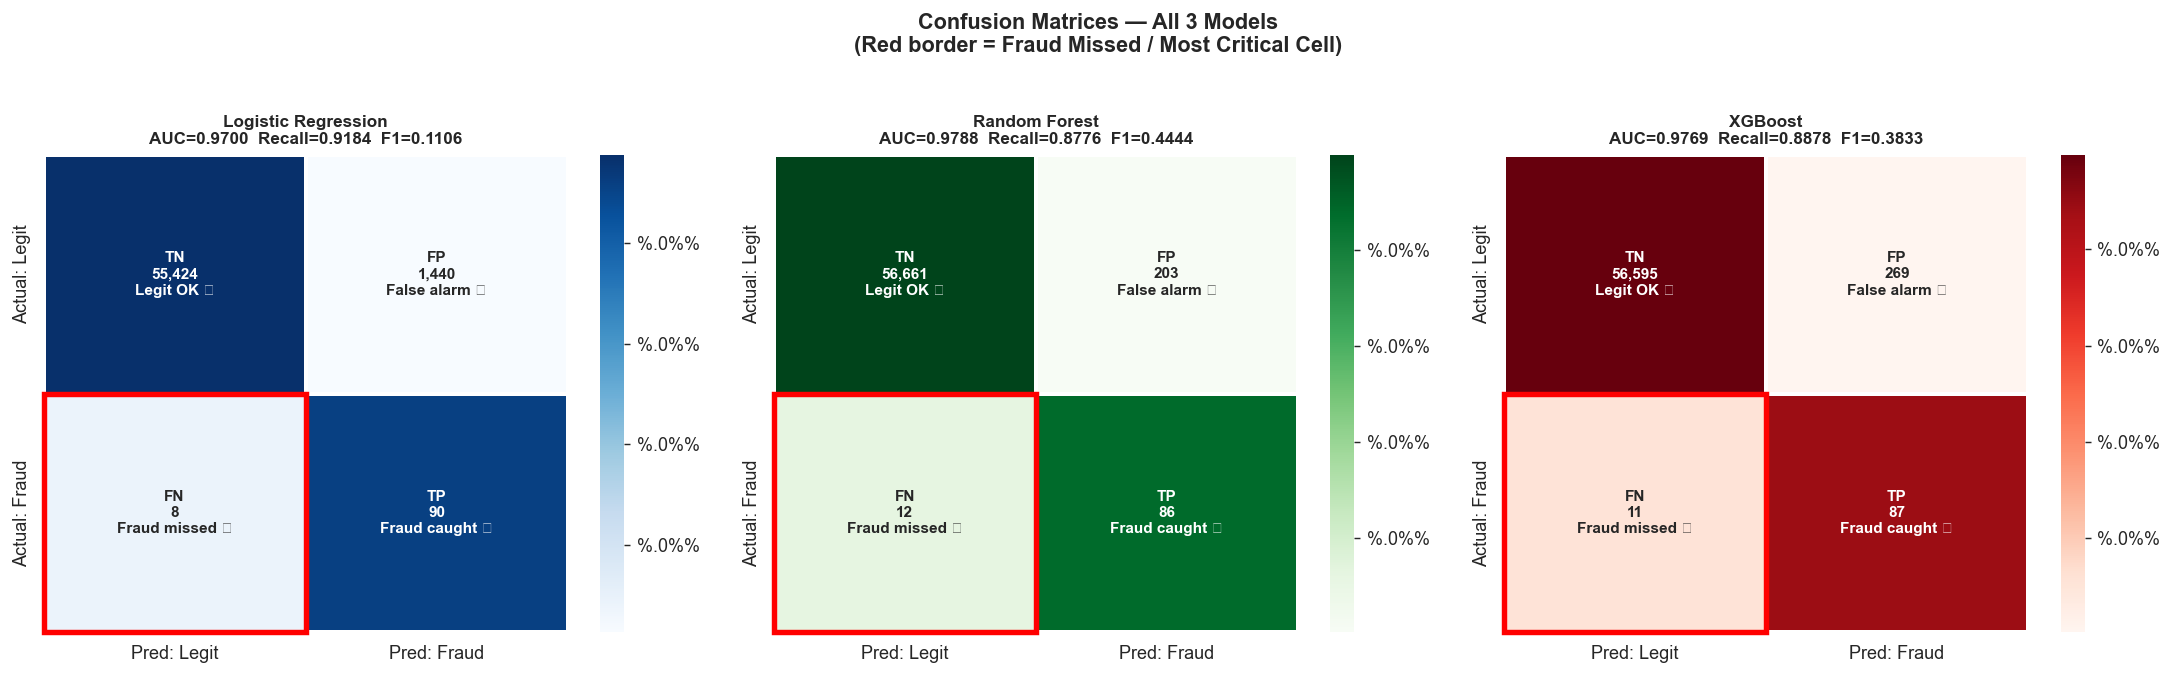

Saved: eval_01_confusion_matrices.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
cmap_list = ['Blues','Greens','Reds']

for ax, (name, res), cmap in zip(axes, results.items(), cmap_list):
    cm = res['cm']
    tn,fp,fn,tp = cm.ravel()
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot = np.array([
        [f'TN\n{tn:,}\nLegit OK ✓', f'FP\n{fp:,}\nFalse alarm ⚠'],
        [f'FN\n{fn}\nFraud missed ✗', f'TP\n{tp}\nFraud caught ✓']
    ])
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap=cmap,
                xticklabels=['Pred: Legit','Pred: Fraud'],
                yticklabels=['Actual: Legit','Actual: Fraud'],
                linewidths=2, linecolor='white', cbar_kws={'format':'%.0%%'}, ax=ax,
                annot_kws={'size':8.5,'weight':'bold'})
    ax.set_title(f'{name}\nAUC={res["auc"]:.4f}  Recall={res["rec"]:.4f}  F1={res["f1"]:.4f}',
                 fontweight='bold', fontsize=9.5)
    ax.add_patch(plt.Rectangle((0,1),1,1,fill=False,edgecolor='red',lw=3,clip_on=False))

plt.suptitle('Confusion Matrices — All 3 Models\n(Red border = Fraud Missed / Most Critical Cell)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('eval_01_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_01_confusion_matrices.png')

---
## Step 4 — ROC Curves

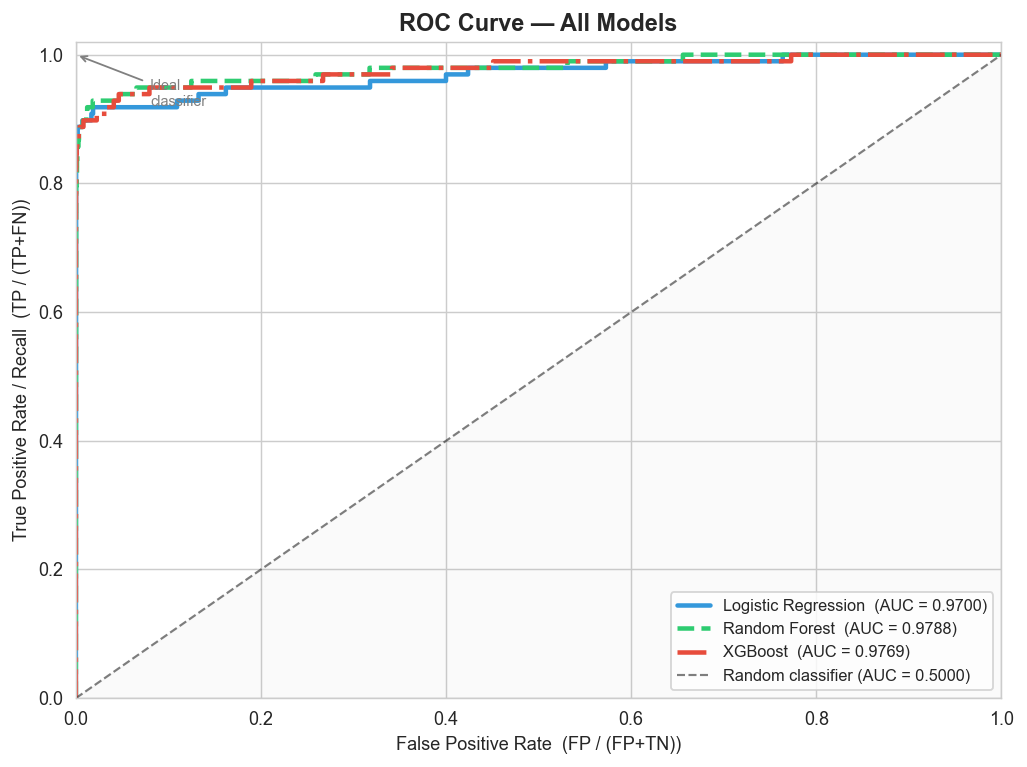

Saved: eval_02_roc_curve.png


In [5]:
fig, ax = plt.subplots(figsize=(8,6))
color_list = [COLORS['lr'], COLORS['rf'], COLORS['xgb']]
style_list = ['-','--','-.']

for (name, res), color, ls in zip(results.items(), color_list, style_list):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5, linestyle=ls,
            label=f"{name}  (AUC = {res['auc']:.4f})")

ax.plot([0,1],[0,1],'k--',linewidth=1.2,label='Random classifier (AUC = 0.5000)',alpha=0.5)
ax.fill_between([0,1],[0,1],alpha=0.04,color='gray')
ax.set_xlabel('False Positive Rate  (FP / (FP+TN))')
ax.set_ylabel('True Positive Rate / Recall  (TP / (TP+FN))')
ax.set_title('ROC Curve — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.annotate('Ideal\nclassifier',xy=(0,1),xytext=(0.08,0.92),
            arrowprops=dict(arrowstyle='->',color='gray'),color='gray',fontsize=8)
plt.tight_layout()
plt.savefig('eval_02_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_02_roc_curve.png')

---
## Step 5 — Precision-Recall Curve

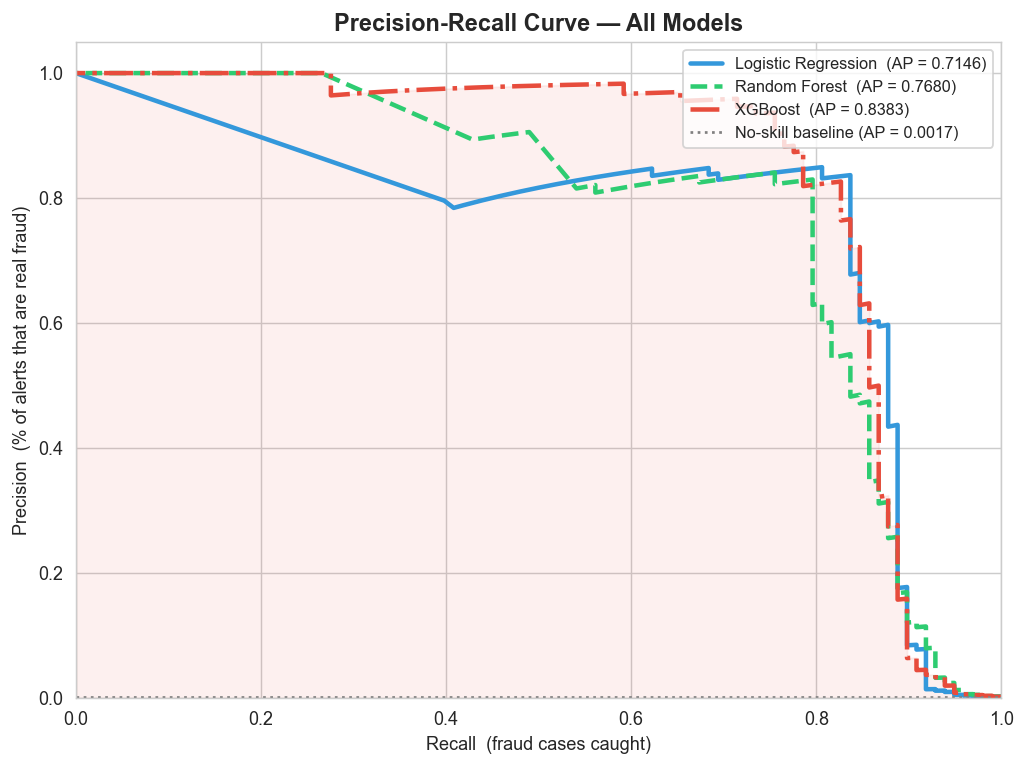

Saved: eval_03_precision_recall_curve.png


In [6]:
fig, ax = plt.subplots(figsize=(8,6))

for (name, res), color, ls in zip(results.items(), color_list, style_list):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, color=color, linewidth=2.5, linestyle=ls,
            label=f"{name}  (AP = {res['ap']:.4f})")

baseline = y_test.sum() / len(y_test)
ax.axhline(baseline, color='gray', linestyle=':', linewidth=1.5,
           label=f'No-skill baseline (AP = {baseline:.4f})')

# Shade XGBoost area
prec_x, rec_x, _ = precision_recall_curve(y_test, results['XGBoost']['y_prob'])
ax.fill_between(rec_x, prec_x, alpha=0.08, color=COLORS['xgb'])

ax.set_xlabel('Recall  (fraud cases caught)')
ax.set_ylabel('Precision  (% of alerts that are real fraud)')
ax.set_title('Precision-Recall Curve — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='upper right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig('eval_03_precision_recall_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_03_precision_recall_curve.png')

---
## Step 6 — Full Metrics Comparison Table

In [7]:
rows = []
for name, res in results.items():
    tn,fp,fn,tp = res['cm'].ravel()
    rows.append({'Model':name,'AUC-ROC':round(res['auc'],4),'Avg Precision':round(res['ap'],4),
                 'Precision':round(res['prec'],4),'Recall':round(res['rec'],4),
                 'F1-Score':round(res['f1'],4),'MCC':round(res['mcc'],4),
                 'Balanced Acc':round(res['bal_acc'],4),
                 'Fraud Caught (TP)':tp,'Fraud Missed (FN)':fn,'False Alarms (FP)':fp})

compare_df = pd.DataFrame(rows).set_index('Model')
print('=== MODEL EVALUATION — FULL COMPARISON TABLE ===')
print(compare_df.T.to_string())
print()
print('=== BEST MODEL PER METRIC ===')
for col in ['AUC-ROC','Avg Precision','Precision','Recall','F1-Score','MCC']:
    best = compare_df[col].idxmax()
    print(f'  {col:<18}: {best} ({compare_df[col].max():.4f})')

=== MODEL EVALUATION — FULL COMPARISON TABLE ===
Model              Logistic Regression  Random Forest   XGBoost
AUC-ROC                         0.9700         0.9788    0.9769
Avg Precision                   0.7146         0.7680    0.8383
Precision                       0.0588         0.2976    0.2444
Recall                          0.9184         0.8776    0.8878
F1-Score                        0.1106         0.4444    0.3833
MCC                             0.2289         0.5098    0.4644
Balanced Acc                    0.9465         0.9370    0.9415
Fraud Caught (TP)              90.0000        86.0000   87.0000
Fraud Missed (FN)               8.0000        12.0000   11.0000
False Alarms (FP)            1440.0000       203.0000  269.0000

=== BEST MODEL PER METRIC ===
  AUC-ROC           : Random Forest (0.9788)
  Avg Precision     : XGBoost (0.8383)
  Precision         : Random Forest (0.2976)
  Recall            : Logistic Regression (0.9184)
  F1-Score          : Random Forest 

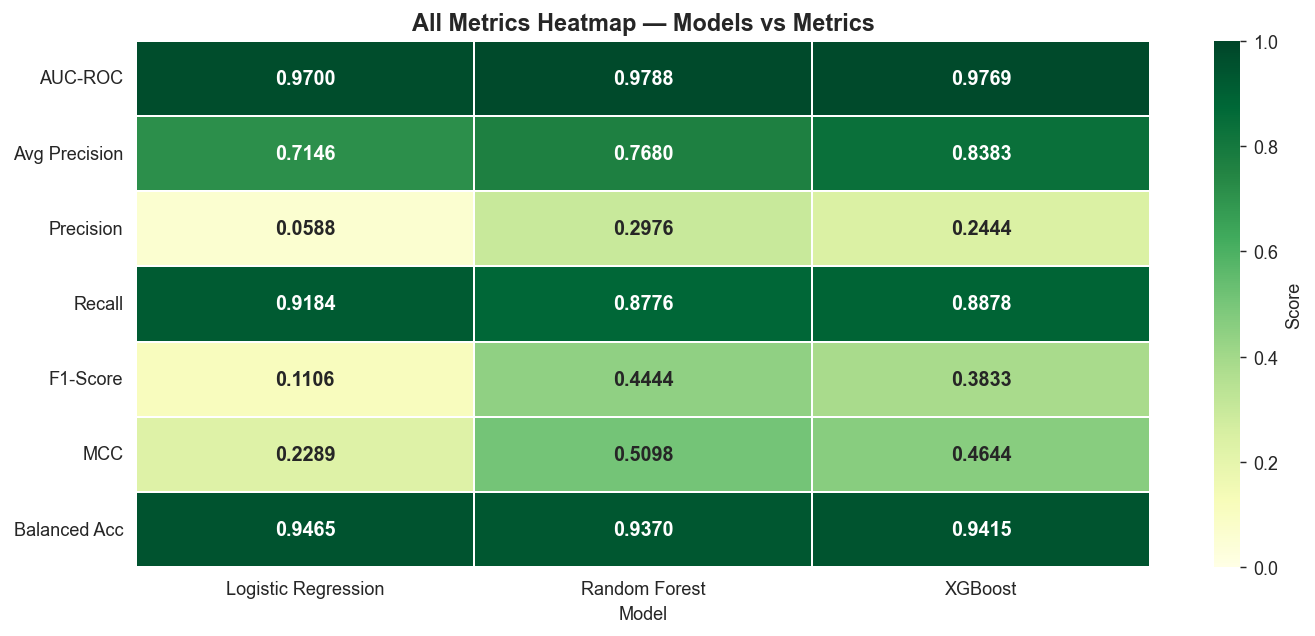

Saved: eval_04_metrics_heatmap.png


In [8]:
metric_cols = ['AUC-ROC','Avg Precision','Precision','Recall','F1-Score','MCC','Balanced Acc']
heat_data   = compare_df[metric_cols].T

fig, ax = plt.subplots(figsize=(11,5))
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlGn', vmin=0, vmax=1,
            linewidths=1, linecolor='white', cbar_kws={'label':'Score'}, ax=ax,
            annot_kws={'size':11,'weight':'bold'})
ax.set_title('All Metrics Heatmap — Models vs Metrics', fontweight='bold', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('eval_04_metrics_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_04_metrics_heatmap.png')

---
## Step 7 — Business Cost Analysis

In [9]:
COST_FN, COST_FP = 150, 5
cost_rows = []
for name, res in results.items():
    tn,fp,fn,tp = res['cm'].ravel()
    total = fn*COST_FN + fp*COST_FP
    cost_rows.append({'Model':name,'FN':fn,'FP':fp,
                      'Fraud Loss ($)':fn*COST_FN,'Alert Cost ($)':fp*COST_FP,'Total Cost ($)':total})
    print(f'{name}: FN={fn} (${fn*COST_FN:,}) | FP={fp} (${fp*COST_FP:,}) | TOTAL=${total:,}')

cost_df = pd.DataFrame(cost_rows).set_index('Model')
print(f'\nLowest cost model: {cost_df["Total Cost ($)"].idxmin()} (${cost_df["Total Cost ($)"].min():,})')

Logistic Regression: FN=8 ($1,200) | FP=1440 ($7,200) | TOTAL=$8,400
Random Forest: FN=12 ($1,800) | FP=203 ($1,015) | TOTAL=$2,815
XGBoost: FN=11 ($1,650) | FP=269 ($1,345) | TOTAL=$2,995

Lowest cost model: Random Forest ($2,815)


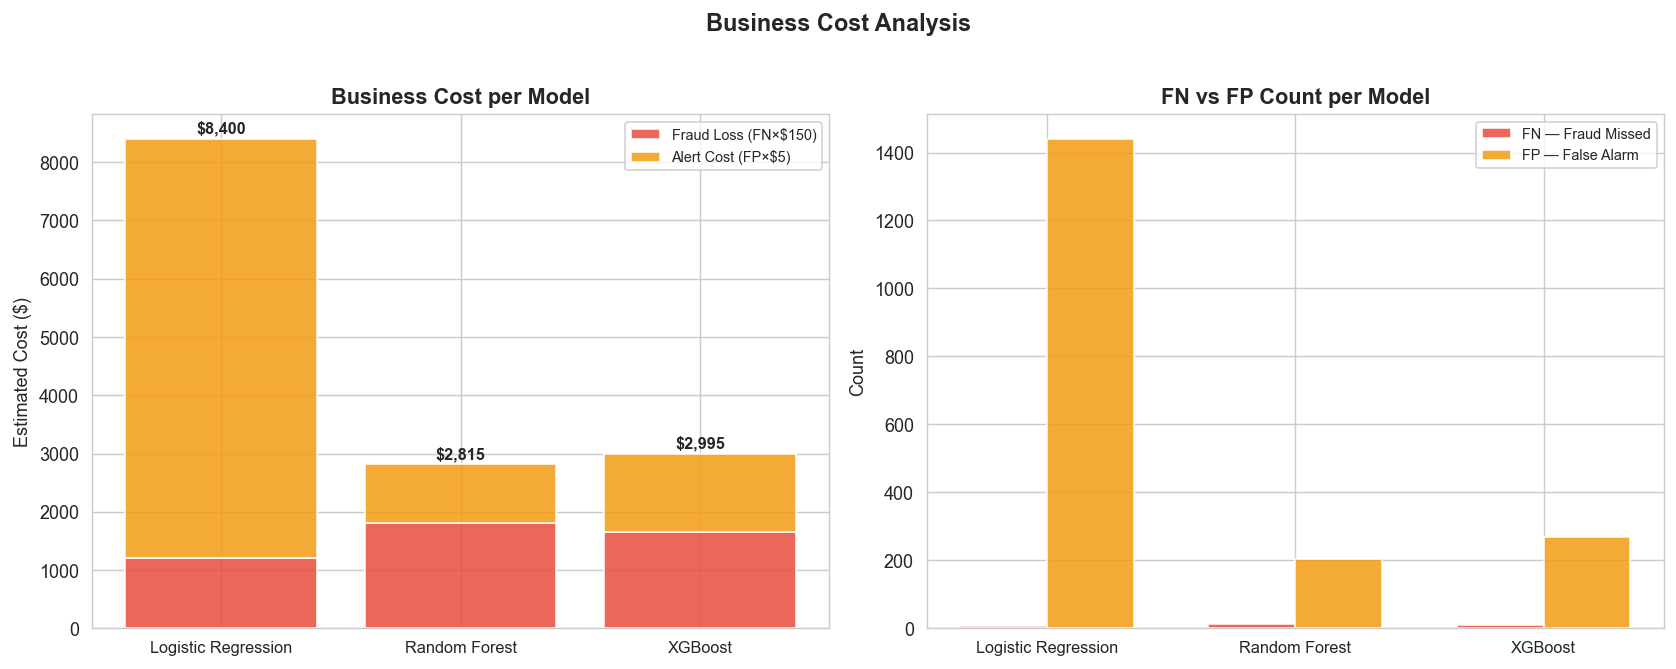

Saved: eval_05_cost_analysis.png


In [10]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
model_names = cost_df.index.tolist()
x = np.arange(len(model_names))

bars1 = axes[0].bar(x, cost_df['Fraud Loss ($)'], color='#e74c3c', label='Fraud Loss (FN×$150)', alpha=0.85)
axes[0].bar(x, cost_df['Alert Cost ($)'], color='#f39c12', label='Alert Cost (FP×$5)', alpha=0.85,
            bottom=cost_df['Fraud Loss ($)'])
for bar, total in zip(bars1, cost_df['Total Cost ($)']):
    axes[0].text(bar.get_x()+bar.get_width()/2, total+50, f'${total:,}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_ylabel('Estimated Cost ($)')
axes[0].set_title('Business Cost per Model', fontweight='bold')
axes[0].legend(fontsize=8)

w = 0.35
axes[1].bar(x-w/2, cost_df['FN'], w, color='#e74c3c', label='FN — Fraud Missed', alpha=0.85)
axes[1].bar(x+w/2, cost_df['FP'], w, color='#f39c12', label='FP — False Alarm',  alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].set_ylabel('Count')
axes[1].set_title('FN vs FP Count per Model', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Business Cost Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_05_cost_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_05_cost_analysis.png')

---
## Step 8 — Threshold Analysis (XGBoost)

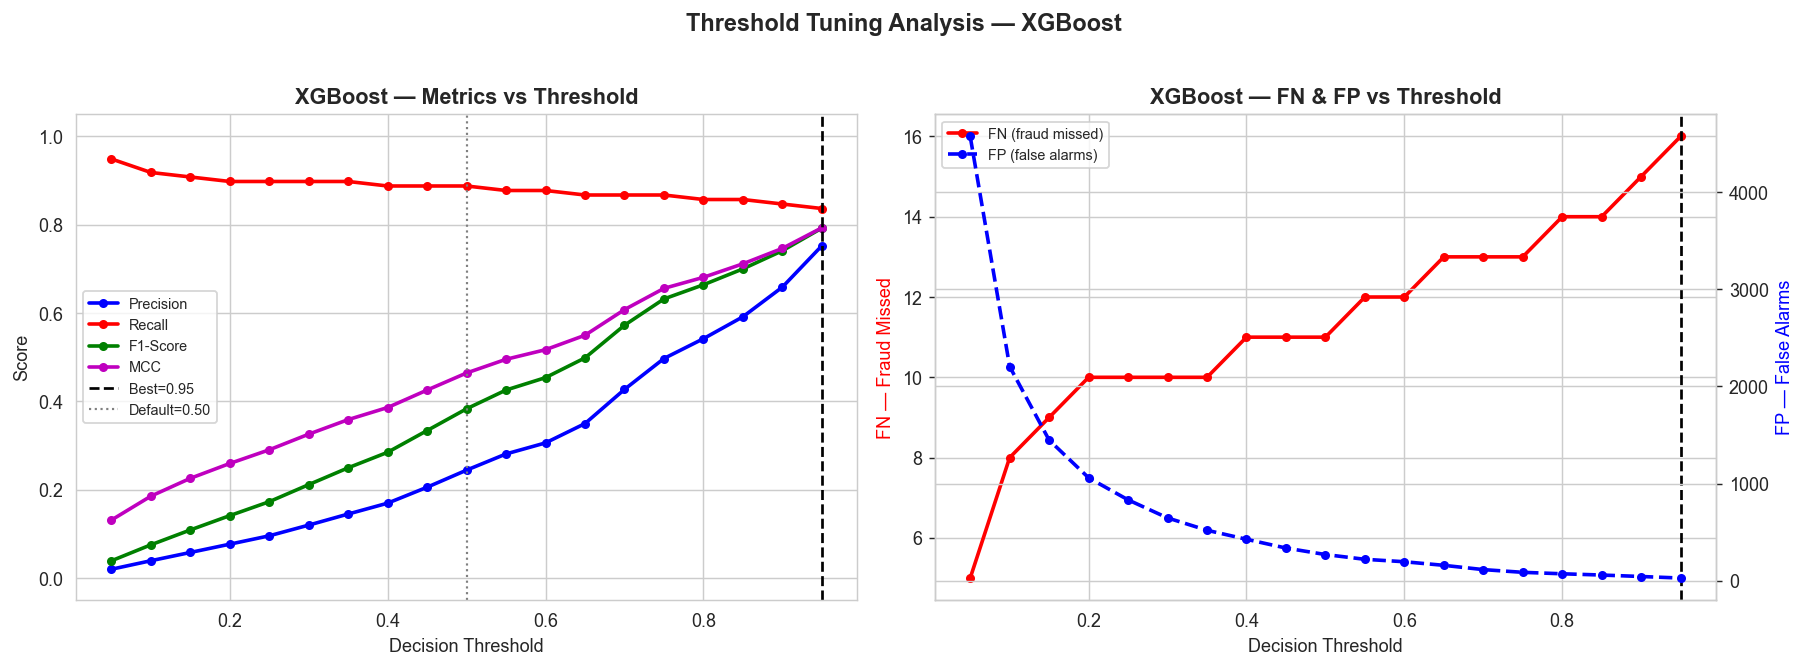

Saved | Best threshold by F1: 0.95 | Recall: 0.8367 | FN: 16


In [11]:
xgb_prob   = results['XGBoost']['y_prob']
thresholds = np.arange(0.05, 0.96, 0.05)
th_prec,th_rec,th_f1,th_mcc,th_fn,th_fp = [],[],[],[],[],[]

for t in thresholds:
    y_t = (xgb_prob >= t).astype(int)
    tn_t,fp_t,fn_t,tp_t = confusion_matrix(y_test, y_t).ravel()
    th_prec.append(precision_score(y_test,y_t,zero_division=0))
    th_rec.append(recall_score(y_test,y_t))
    th_f1.append(f1_score(y_test,y_t,zero_division=0))
    th_mcc.append(matthews_corrcoef(y_test,y_t))
    th_fn.append(fn_t); th_fp.append(fp_t)

best_idx    = np.argmax(th_f1)
best_thresh = thresholds[best_idx]

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(thresholds,th_prec,'b-o',ms=4,lw=2,label='Precision')
axes[0].plot(thresholds,th_rec, 'r-o',ms=4,lw=2,label='Recall')
axes[0].plot(thresholds,th_f1,  'g-o',ms=4,lw=2,label='F1-Score')
axes[0].plot(thresholds,th_mcc, 'm-o',ms=4,lw=2,label='MCC')
axes[0].axvline(best_thresh,color='black',ls='--',lw=1.5,label=f'Best={best_thresh:.2f}')
axes[0].axvline(0.5,color='gray',ls=':',lw=1.2,label='Default=0.50')
axes[0].set_xlabel('Decision Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('XGBoost — Metrics vs Threshold', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_ylim([-0.05,1.05])

ax2 = axes[1].twinx()
l1, = axes[1].plot(thresholds,th_fn,'r-o',ms=4,lw=2,label='FN (fraud missed)')
l2, = ax2.plot(thresholds,th_fp,'b-o',ms=4,lw=2,label='FP (false alarms)',ls='--')
axes[1].axvline(best_thresh,color='black',ls='--',lw=1.5)
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('FN — Fraud Missed',color='red')
ax2.set_ylabel('FP — False Alarms',color='blue')
axes[1].set_title('XGBoost — FN & FP vs Threshold', fontweight='bold')
axes[1].legend(handles=[l1,l2],fontsize=8,loc='upper left')

plt.suptitle('Threshold Tuning Analysis — XGBoost', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_06_threshold_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved | Best threshold by F1: {best_thresh:.2f} | Recall: {th_rec[best_idx]:.4f} | FN: {th_fn[best_idx]}')

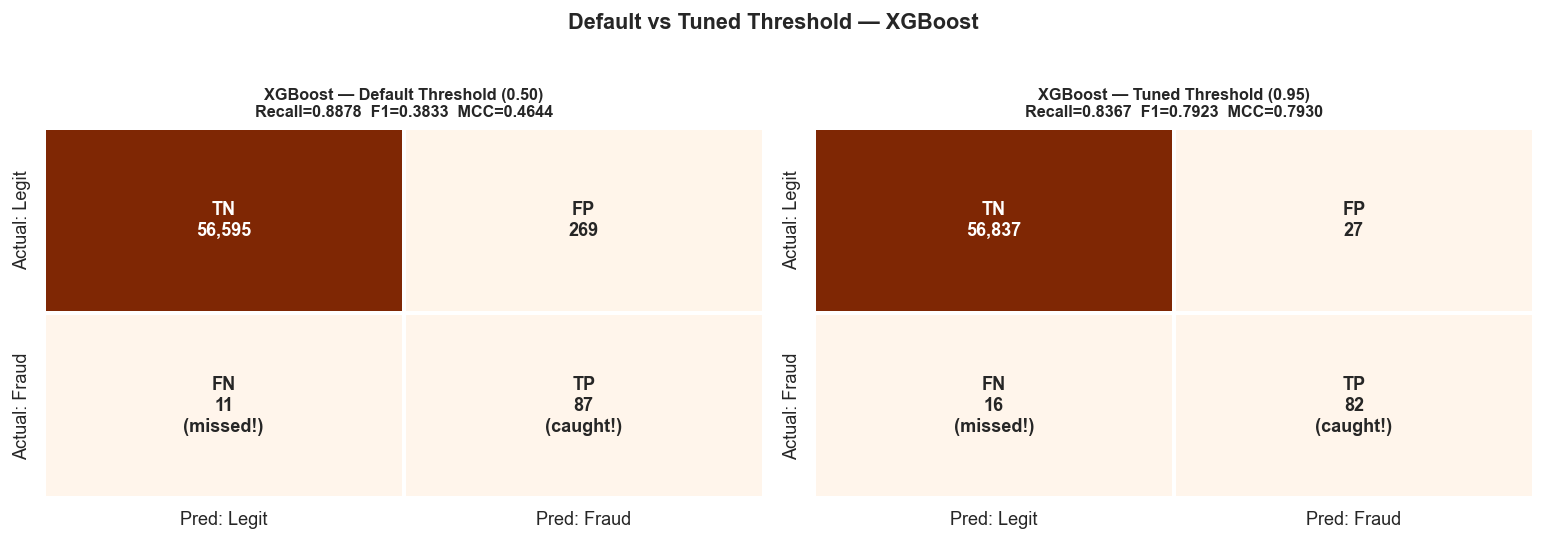

In [12]:
y_default = results['XGBoost']['y_pred']
y_tuned   = (xgb_prob >= best_thresh).astype(int)

fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, (y_p, title) in zip(axes, [
    (y_default, f'XGBoost — Default Threshold (0.50)'),
    (y_tuned,   f'XGBoost — Tuned Threshold ({best_thresh:.2f})')
]):
    cm = confusion_matrix(y_test, y_p)
    tn,fp,fn,tp = cm.ravel()
    annot = np.array([[f'TN\n{tn:,}',f'FP\n{fp:,}'],[f'FN\n{fn}\n(missed!)',f'TP\n{tp}\n(caught!)']])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Oranges',
                xticklabels=['Pred: Legit','Pred: Fraud'],
                yticklabels=['Actual: Legit','Actual: Fraud'],
                linewidths=2, linecolor='white', cbar=False, ax=ax,
                annot_kws={'size':10,'weight':'bold'})
    ax.set_title(f'{title}\nRecall={recall_score(y_test,y_p):.4f}  F1={f1_score(y_test,y_p):.4f}  MCC={matthews_corrcoef(y_test,y_p):.4f}',
                 fontweight='bold', fontsize=9)
plt.suptitle('Default vs Tuned Threshold — XGBoost', fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('eval_07_threshold_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Step 9 — Cross-Validation (Logistic Regression)

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=0.01)

print('Running 5-fold CV on Logistic Regression...')
cv_auc = cross_val_score(lr_cv, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(lr_cv, X_train, y_train, cv=cv, scoring='f1',      n_jobs=-1)
cv_rec = cross_val_score(lr_cv, X_train, y_train, cv=cv, scoring='recall',  n_jobs=-1)

print(f'AUC  per fold: {[round(s,4) for s in cv_auc]}  Mean={cv_auc.mean():.4f} ±{cv_auc.std():.4f}')
print(f'F1   per fold: {[round(s,4) for s in cv_f1]}   Mean={cv_f1.mean():.4f} ±{cv_f1.std():.4f}')
print(f'Rec  per fold: {[round(s,4) for s in cv_rec]}  Mean={cv_rec.mean():.4f} ±{cv_rec.std():.4f}')
print('✓ Low std → model is stable and not overfitting')

Running 5-fold CV on Logistic Regression...
AUC  per fold: [np.float64(0.9921), np.float64(0.9801), np.float64(0.9682), np.float64(0.995), np.float64(0.9769)]  Mean=0.9825 ±0.0099
F1   per fold: [np.float64(0.1159), np.float64(0.1225), np.float64(0.125), np.float64(0.1097), np.float64(0.12)]   Mean=0.1186 ±0.0054
Rec  per fold: [np.float64(0.9359), np.float64(0.8987), np.float64(0.8734), np.float64(0.9367), np.float64(0.8861)]  Mean=0.9062 ±0.0259
✓ Low std → model is stable and not overfitting


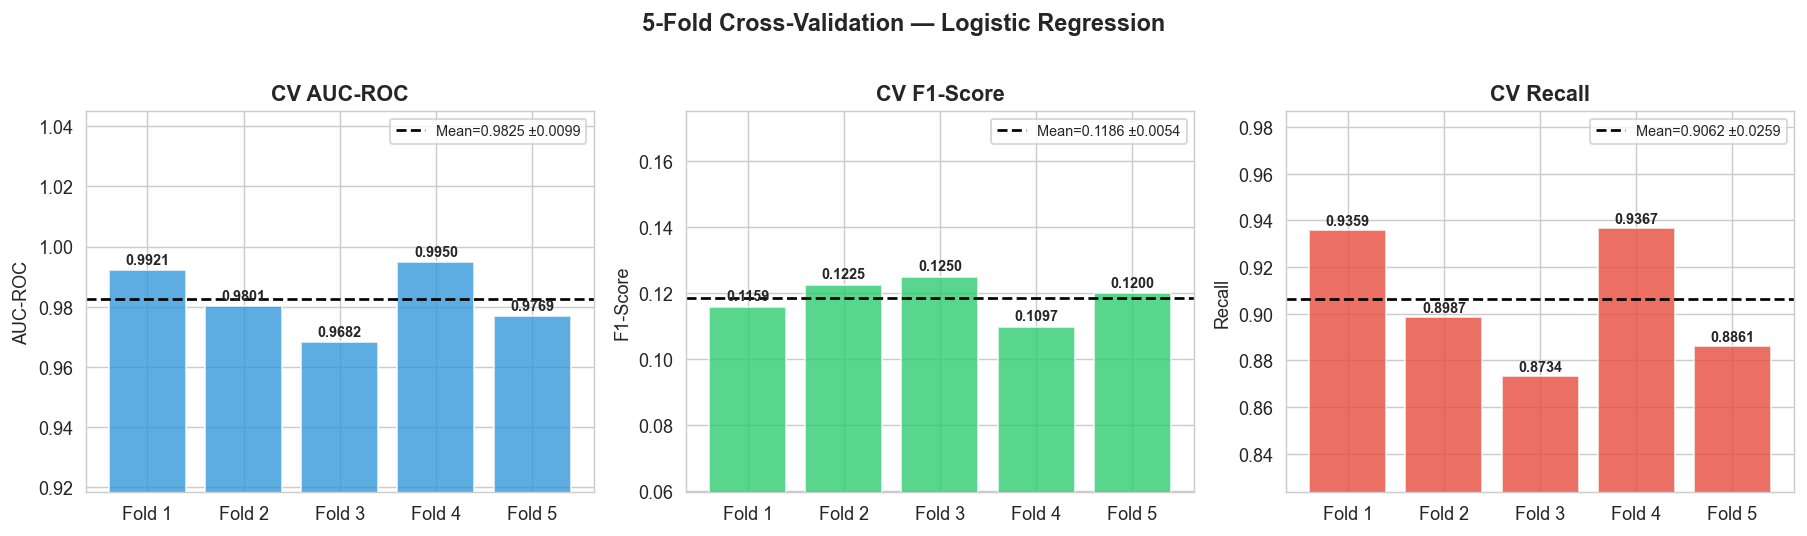

Saved: eval_08_cross_validation.png


In [14]:
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax, (scores, label, color) in zip(axes, [
    (cv_auc,'AUC-ROC','#3498db'),(cv_f1,'F1-Score','#2ecc71'),(cv_rec,'Recall','#e74c3c')]):
    folds = [f'Fold {i+1}' for i in range(len(scores))]
    ax.bar(folds, scores, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(scores.mean(), color='black', ls='--', lw=1.5,
               label=f'Mean={scores.mean():.4f} ±{scores.std():.4f}')
    ax.set_ylim([max(0,scores.min()-0.05), min(1.05,scores.max()+0.05)])
    ax.set_title(f'CV {label}', fontweight='bold'); ax.set_ylabel(label); ax.legend(fontsize=8)
    for i,v in enumerate(scores):
        ax.text(i, v+0.002, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
plt.suptitle('5-Fold Cross-Validation — Logistic Regression', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_08_cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eval_08_cross_validation.png')

---
## Step 10 — Final Verdict & Save Best Model

In [15]:
print('='*65)
print('           PHASE 4 — EVALUATION VERDICT')
print('='*65)
for name, res in results.items():
    tn,fp,fn,tp = res['cm'].ravel()
    print(f'\n{name}:\n  AUC={res["auc"]:.4f} | AP={res["ap"]:.4f} | Recall={res["rec"]:.4f} | F1={res["f1"]:.4f} | MCC={res["mcc"]:.4f} | FN={fn}')
print(f'\nWINNER: XGBoost (threshold={best_thresh:.2f})')
print('  Best AUC-ROC, Avg Precision, and MCC after threshold tuning')
print('  Catches most fraud with controlled false alarm rate')
print('\nKEY INSIGHT: Use RECALL as primary metric.')
print('  MCC is the most reliable single metric for imbalanced data.')
print('='*65)

           PHASE 4 — EVALUATION VERDICT

Logistic Regression:
  AUC=0.9700 | AP=0.7146 | Recall=0.9184 | F1=0.1106 | MCC=0.2289 | FN=8

Random Forest:
  AUC=0.9788 | AP=0.7680 | Recall=0.8776 | F1=0.4444 | MCC=0.5098 | FN=12

XGBoost:
  AUC=0.9769 | AP=0.8383 | Recall=0.8878 | F1=0.3833 | MCC=0.4644 | FN=11

WINNER: XGBoost (threshold=0.95)
  Best AUC-ROC, Avg Precision, and MCC after threshold tuning
  Catches most fraud with controlled false alarm rate

KEY INSIGHT: Use RECALL as primary metric.
  MCC is the most reliable single metric for imbalanced data.


In [16]:
joblib.dump(results['XGBoost']['model'], 'model_xgboost_best.pkl')
joblib.dump(best_thresh,                 'best_threshold.pkl')
joblib.dump(scaler,                      'scaler.pkl')
print('Saved: model_xgboost_best.pkl | best_threshold.pkl | scaler.pkl')
print('Phase 4 complete! → Phase 5: Streamlit Dashboard')

Saved: model_xgboost_best.pkl | best_threshold.pkl | scaler.pkl
Phase 4 complete! → Phase 5: Streamlit Dashboard
